Mark Joseph C. Nicasio

4CSC

Machine Problem

## 1.) Translate the prism in the last activity using the parameter [5, 7, 2]

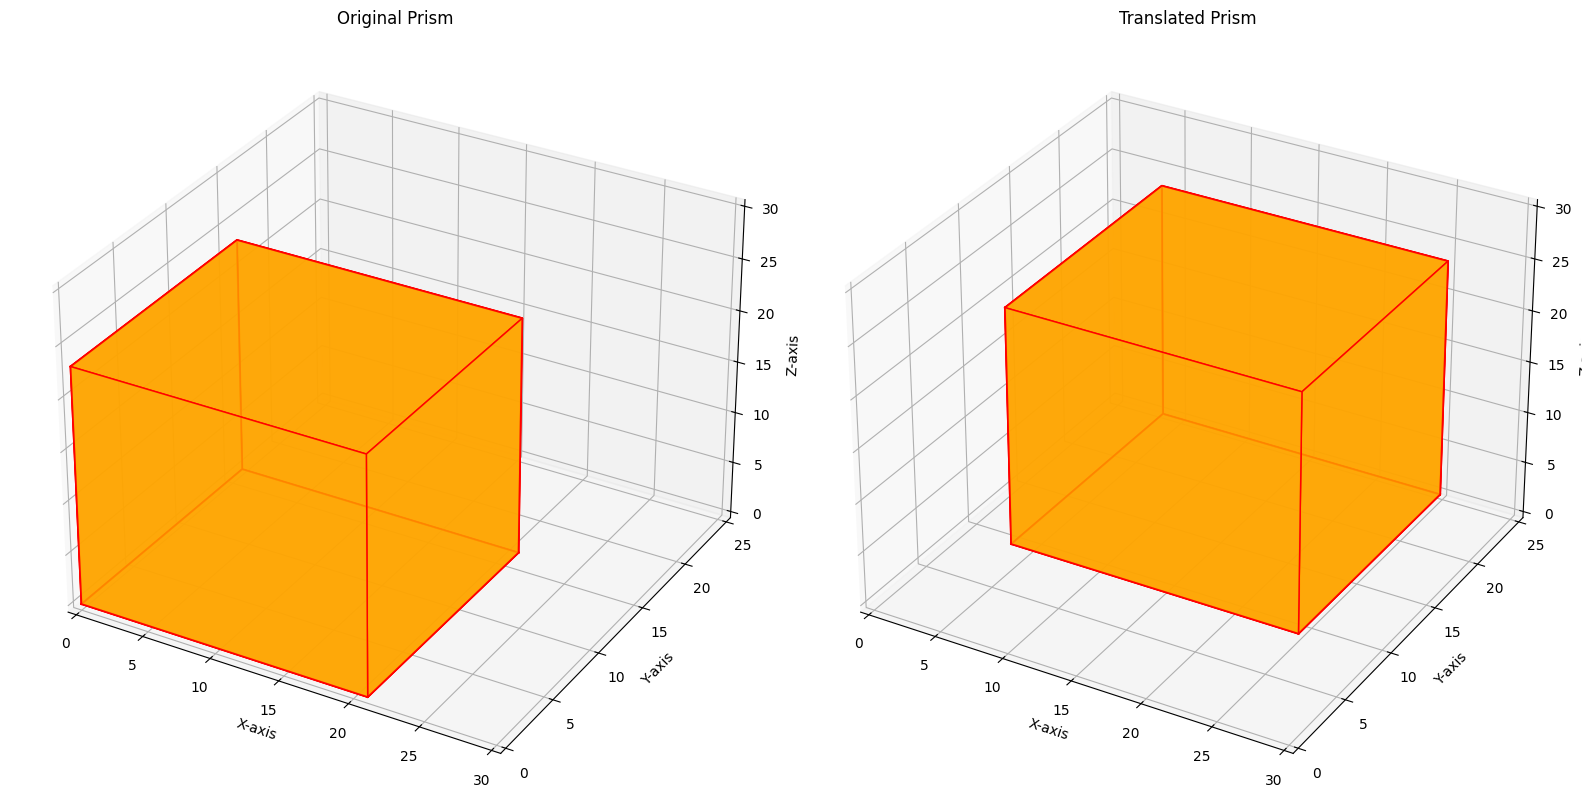

Volume of Original Prism: 7728
Volume of Translated Prism: 7728


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def draw_prism(ax, base_dims, height, color, edge_color, translation=(0, 0, 0)):
    L, W = base_dims
    tx, ty, tz = translation
    
    vertices = [
        [0 + tx, 0 + ty, 0 + tz],         
        [L + tx, 0 + ty, 0 + tz],          
        [L + tx, W + ty, 0 + tz],        
        [0 + tx, W + ty, 0 + tz],          
        [0 + tx, 0 + ty, height + tz],   
        [L + tx, 0 + ty, height + tz],    
        [L + tx, W + ty, height + tz],     
        [0 + tx, W + ty, height + tz],    
    ]
    
    faces = [
        [vertices[0], vertices[1], vertices[5], vertices[4]],  
        [vertices[1], vertices[2], vertices[6], vertices[5]],  
        [vertices[2], vertices[3], vertices[7], vertices[6]],  
        [vertices[3], vertices[0], vertices[4], vertices[7]],  
        [vertices[4], vertices[5], vertices[6], vertices[7]], 
        [vertices[0], vertices[1], vertices[2], vertices[3]],  
    ]
    
    poly3d = Poly3DCollection(faces, facecolors=color, edgecolors=edge_color, alpha=0.8)
    ax.add_collection3d(poly3d)
    
    for face in faces:
        ax.plot([v[0] for v in face + [face[0]]],
                [v[1] for v in face + [face[0]]],
                [v[2] for v in face + [face[0]]], color=edge_color)
   
    return L * W * height


fig = plt.figure(figsize=(16, 8))

# Original Prism
ax1 = fig.add_subplot(121, projection='3d')
vol_original = draw_prism(ax1, (21, 16), 23, 'orange', 'red')
ax1.set_title("Original Prism")
ax1.set_xlim([0, 30])
ax1.set_ylim([0, 25])
ax1.set_zlim([0, 30])
ax1.set_xlabel('X-axis')
ax1.set_ylabel('Y-axis')
ax1.set_zlabel('Z-axis')

# Translated Prism
ax2 = fig.add_subplot(122, projection='3d')
vol_translated = draw_prism(ax2, (21, 16), 23, 'orange', 'red', translation=(5, 7, 2))
ax2.set_title("Translated Prism")
ax2.set_xlim([0, 30])
ax2.set_ylim([0, 25])
ax2.set_zlim([0, 30])
ax2.set_xlabel('X-axis')
ax2.set_ylabel('Y-axis')
ax2.set_zlabel('Z-axis')

plt.tight_layout()
plt.show()

print("Volume of Original Prism:", vol_original)
print("Volume of Translated Prism:", vol_translated)


## 2.) Scale the cube in the last activity using the parameter [0, 2, 1]


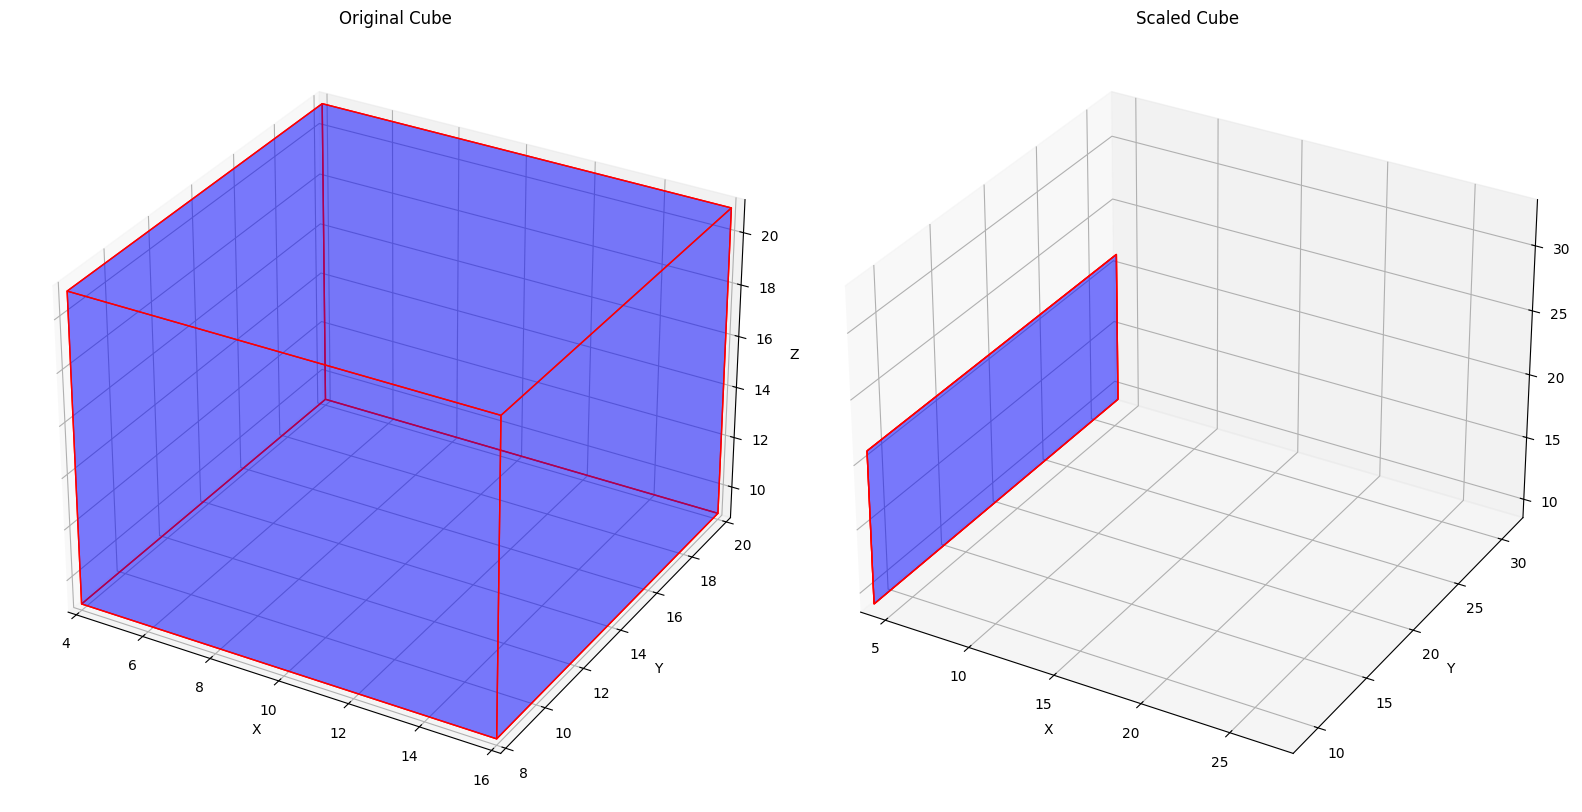

Volume of the original cube: 1728
Volume of the scaled cube: 0


In [8]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


initial_coord = (4, 8, 9)
edge_length = 12

def calculate_scaled_vertices(vertices, scale_factors):
    return vertices * np.array(scale_factors)

# Define original vertices
vertices = np.array([
    [initial_coord[0], initial_coord[1], initial_coord[2]], 
    [initial_coord[0] + edge_length, initial_coord[1], initial_coord[2]], 
    [initial_coord[0] + edge_length, initial_coord[1] + edge_length, initial_coord[2]],  
    [initial_coord[0], initial_coord[1] + edge_length, initial_coord[2]], 
    [initial_coord[0], initial_coord[1], initial_coord[2] + edge_length], 
    [initial_coord[0] + edge_length, initial_coord[1], initial_coord[2] + edge_length],  
    [initial_coord[0] + edge_length, initial_coord[1] + edge_length, initial_coord[2] + edge_length], 
    [initial_coord[0], initial_coord[1] + edge_length, initial_coord[2] + edge_length]  
])

# Define faces
faces = [
    [vertices[0], vertices[1], vertices[2], vertices[3]],  
    [vertices[4], vertices[5], vertices[6], vertices[7]],  
    [vertices[0], vertices[1], vertices[5], vertices[4]], 
    [vertices[2], vertices[3], vertices[7], vertices[6]],  
    [vertices[1], vertices[2], vertices[6], vertices[5]], 
    [vertices[4], vertices[7], vertices[3], vertices[0]]  
]

# Scale factors
scale_factors = [0, 2, 1]
scaled_vertices = calculate_scaled_vertices(vertices - vertices[0], scale_factors) + vertices[0]

# Define scaled faces
scaled_faces = [
    [scaled_vertices[0], scaled_vertices[1], scaled_vertices[2], scaled_vertices[3]],  
    [scaled_vertices[4], scaled_vertices[5], scaled_vertices[6], scaled_vertices[7]],  
    [scaled_vertices[0], scaled_vertices[1], scaled_vertices[5], scaled_vertices[4]],  
    [scaled_vertices[2], scaled_vertices[3], scaled_vertices[7], scaled_vertices[6]],  
    [scaled_vertices[1], scaled_vertices[2], scaled_vertices[6], scaled_vertices[5]],  
    [scaled_vertices[4], scaled_vertices[7], scaled_vertices[3], scaled_vertices[0]]  
]

# Plotting
fig = plt.figure(figsize=(16, 8))

# Original cube
ax1 = fig.add_subplot(121, projection='3d')
ax1.add_collection3d(Poly3DCollection(faces, facecolors='blue', linewidths=1, edgecolors='red', alpha=.30))
ax1.set_title("Original Cube")
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_xlim([initial_coord[0], initial_coord[0] + edge_length])
ax1.set_ylim([initial_coord[1], initial_coord[1] + edge_length])
ax1.set_zlim([initial_coord[2], initial_coord[2] + edge_length])

# Scaled cube
ax2 = fig.add_subplot(122, projection='3d')
ax2.add_collection3d(Poly3DCollection(scaled_faces, facecolors='blue', linewidths=1, edgecolors='red', alpha=.30))
ax2.set_title("Scaled Cube")
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_xlim([initial_coord[0], initial_coord[0] + edge_length * max(scale_factors)])
ax2.set_ylim([initial_coord[1], initial_coord[1] + edge_length * max(scale_factors)])
ax2.set_zlim([initial_coord[2], initial_coord[2] + edge_length * max(scale_factors)])

plt.tight_layout()
plt.show()

# Volume calculations
original_volume = edge_length ** 3
scaled_volume = edge_length ** 3 * np.prod(scale_factors)
print(f"Volume of the original cube: {original_volume}")
print(f"Volume of the scaled cube: {scaled_volume}")


## 3.) Rotate the pyramid in the last activity using 120 degrees about x, y and z axis.

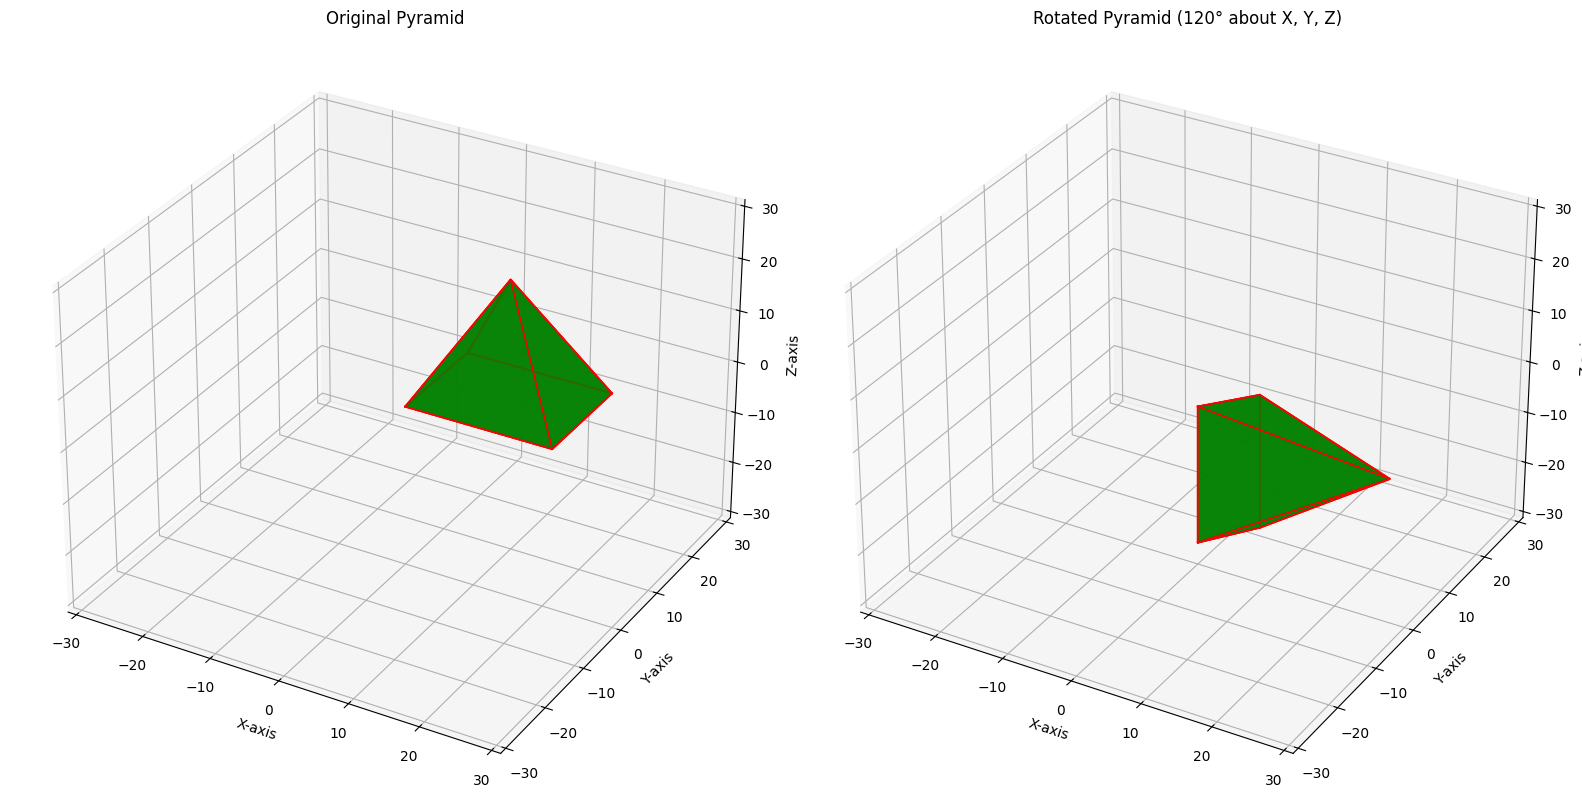

Volume of Pyramid: 2576.0


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


# Rotation matrices
def rotation_matrix(axis, angle_deg):
    angle_rad = np.radians(angle_deg)
    if axis == 'x':
        return np.array([
            [1, 0, 0],
            [0, np.cos(angle_rad), -np.sin(angle_rad)],
            [0, np.sin(angle_rad), np.cos(angle_rad)]
        ])
    elif axis == 'y':
        return np.array([
            [np.cos(angle_rad), 0, np.sin(angle_rad)],
            [0, 1, 0],
            [-np.sin(angle_rad), 0, np.cos(angle_rad)]
        ])
    elif axis == 'z':
        return np.array([
            [np.cos(angle_rad), -np.sin(angle_rad), 0],
            [np.sin(angle_rad), np.cos(angle_rad), 0],
            [0, 0, 1]
        ])


# Draw pyramid function
def draw_pyramid(ax, vertices, color, edge_color):
    faces = [
        [vertices[0], vertices[1], vertices[4]],  
        [vertices[1], vertices[2], vertices[4]],  
        [vertices[2], vertices[3], vertices[4]],  
        [vertices[3], vertices[0], vertices[4]],  
        [vertices[0], vertices[1], vertices[2], vertices[3]],  
    ]
    poly3d = Poly3DCollection(faces, facecolors=color, edgecolors=edge_color, alpha=0.8)
    ax.add_collection3d(poly3d)
    for face in faces:
        ax.plot([v[0] for v in face + [face[0]]],
                [v[1] for v in face + [face[0]]],
                [v[2] for v in face + [face[0]]], color=edge_color)


# Original pyramid vertices
base_dims = (21, 16)
height = 23
L, W = base_dims
original_vertices = np.array([
    [0, 0, 0],
    [L, 0, 0],
    [L, W, 0],
    [0, W, 0],
    [L / 2, W / 2, height]
])

# Rotate the vertices
rot_x = rotation_matrix('x', 120)
rot_y = rotation_matrix('y', 120)
rot_z = rotation_matrix('z', 120)
rotated_vertices = original_vertices @ rot_x.T @ rot_y.T @ rot_z.T

# Plotting
fig = plt.figure(figsize=(16, 8))

# Original Pyramid
ax1 = fig.add_subplot(121, projection='3d')
draw_pyramid(ax1, original_vertices, 'green', 'red')
ax1.set_title("Original Pyramid")
ax1.set_xlim([-30, 30])
ax1.set_ylim([-30, 30])
ax1.set_zlim([-30, 30])
ax1.set_xlabel('X-axis')
ax1.set_ylabel('Y-axis')
ax1.set_zlabel('Z-axis')

# Rotated Pyramid
ax2 = fig.add_subplot(122, projection='3d')
draw_pyramid(ax2, rotated_vertices, 'green', 'red')
ax2.set_title("Rotated Pyramid (120° about X, Y, Z)")
ax2.set_xlim([-30, 30])
ax2.set_ylim([-30, 30])
ax2.set_zlim([-30, 30])
ax2.set_xlabel('X-axis')
ax2.set_ylabel('Y-axis')
ax2.set_zlabel('Z-axis')

plt.tight_layout()
plt.show()

# Volume remains unchanged
vol_pyramid = (1 / 3) * L * W * height
print("Volume of Pyramid:", vol_pyramid)
